# EXHEART_16 — NHANES paired-instrument go/no-go probe

**One question, one number.** The whole measurement-aware-fairness extension rests on a single bet:
does the **sex TPR gap shrink under objective measurement relative to self-report, on the *same* people**?
On BRFSS-vs-Cardio that pattern (0.124 → 0.014) is confounded by population, age range, prevalence and
outcome provenance all changing at once. NHANES breaks the confound: the *same* respondents carry both a
self-reported condition and an objectively measured equivalent, so only the measurement instrument changes.

**Design.** On the identical NHANES adults we build two label sets — self-report (BPQ020 / BPQ080 / DIQ010)
and objective (measured BP / total cholesterol / HbA1c) — train the EXHEART stack (XGB + LGBM + RF + MLP →
OOF logistic meta) **twice**, once per label set, on a shared train/test split, and read the sex TPR gap under
each. Fairness is evaluated at a **matched overall sensitivity** (not a fixed probability threshold), so the
gap is ranking-based and immune to the Platt-calibration divergence that affected EXHEART_15. Calibration and
conformal coverage are deferred to the full study; this probe only needs the ranking.

**Decision rule (read the last cell):**
- **GO** — objective gap materially smaller than self-report gap on the same people, and the paired change CI
  excludes 0. The instrument effect is real and confound-free; build the full method (DIF, SIMEX, E-values,
  conformal-by-instrument).
- **SOFT** — point estimate in the right direction but change CI includes 0. Underpowered; consider the
  2017-2018 auscultatory-BP cycle or a larger composite before committing.
- **NO-GO** — gaps within bootstrap noise, or the wrong sign. Stop; ship EXHEART as it stands.

Nothing downstream gets built until this clears.


## 1. Bootstrap (Drive, git identity, deps)

In [4]:
# === EXHEART_16 bootstrap : restores git identity from Drive root, clones/updates repo, adds src/ to path ===
import os, sys, subprocess
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/EXHEART_Research'
REPO_DIR   = os.path.join(DRIVE_ROOT, 'exheart-research')

# restore git config + credentials saved in Drive root (prevents 'Author identity unknown' / 'could not read Username')
for fn in ['.gitconfig', '.git-credentials']:
    src = os.path.join(DRIVE_ROOT, fn)
    if os.path.exists(src):
        subprocess.run(['cp', src, os.path.join('/root', fn)])

os.makedirs(DRIVE_ROOT, exist_ok=True)
if not os.path.isdir(os.path.join(REPO_DIR, '.git')):
    subprocess.run(['git', 'clone', 'https://github.com/anasbiswas1/exheart-research.git', REPO_DIR])

%cd {REPO_DIR}
SRC = os.path.join(REPO_DIR, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'xgboost', 'lightgbm', 'scikit-learn', 'pandas', 'numpy', 'matplotlib'])
print('bootstrap done | cwd =', os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/EXHEART_Research/exheart-research
bootstrap done | cwd = /content/drive/MyDrive/EXHEART_Research/exheart-research


## 2. Config (paths, NHANES files, thresholds, operating point)

In [5]:
import numpy as np, os
SEED = 42
np.random.seed(SEED)

NB_TAG   = 'EXHEART_16'
OUT_DIR  = os.path.join(REPO_DIR, 'results', 'nhanes_instrument_probe')
TAB_DIR  = os.path.join(OUT_DIR, 'tables')
FIG_DIR  = os.path.join(OUT_DIR, 'figures')
DATA_DIR = os.path.join(REPO_DIR, 'data', 'nhanes')
for d in (TAB_DIR, FIG_DIR, DATA_DIR):
    os.makedirs(d, exist_ok=True)

# --- NHANES pre-pandemic pooled 2017-March 2020 files (P_ prefix). ---
# If the primary base 404s the loader tries the alternate, then falls back to manual files in DATA_DIR.
NHANES_BASE     = 'https://wwwn.cdc.gov/Nchs/Nhanes/2017-2020'
NHANES_BASE_ALT = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles'
NHANES_FILES = {
    'DEMO':'P_DEMO.XPT', 'BPQ':'P_BPQ.XPT', 'BPXO':'P_BPXO.XPT',
    'TCHOL':'P_TCHOL.XPT', 'GHB':'P_GHB.XPT', 'DIQ':'P_DIQ.XPT',
    'BMX':'P_BMX.XPT', 'SMQ':'P_SMQ.XPT',
}

# --- objective thresholds (edit here) ---
HTN_SBP, HTN_DBP = 130, 80     # ACC/AHA 2017; set 140/90 for JNC7
TC_HIGH          = 240         # mg/dL, 'high' total cholesterol
HBA1C_DM         = 6.5         # %

ADULT_MIN_AGE      = 18
TARGET_SENSITIVITY = 0.70      # matched overall sensitivity at which the sex gap is read
BOOT               = 1000
USE_MLP            = True      # False = fast first pass (XGB+LGBM+RF only)

# features: demographics + behaviour + anthropometry ONLY.
# deliberately EXCLUDES measured BP / lipids / HbA1c and their self-reports, which define the labels.
FEATURES = ['AGE', 'SEX', 'BMI', 'SMOKER', 'PIR', 'RACE']
print('config set | target sensitivity =', TARGET_SENSITIVITY, '| MLP =', USE_MLP)


config set | target sensitivity = 0.7 | MLP = True


## 3. Download + merge NHANES on SEQN

In [6]:
import pandas as pd, urllib.request

UA = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                     '(KHTML, like Gecko) Chrome/124.0 Safari/537.36'}

def _is_xport(path):
    try:
        with open(path, 'rb') as f:
            return b'HEADER RECORD' in f.read(80)      # XPORT files begin with this; HTML pages do not
    except Exception:
        return False

def _candidates(fn):
    fl = fn.lower()
    return [f'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/{fn}',
            f'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/{fl}',
            f'https://wwwn.cdc.gov/Nchs/Nhanes/2017-2020/{fn}']

def load_xpt(key):
    fn = NHANES_FILES[key]; local = os.path.join(DATA_DIR, fn)
    if os.path.exists(local) and not _is_xport(local):
        os.remove(local)                                  # purge bad (HTML) cached download
    if not os.path.exists(local):
        got = False
        for url in _candidates(fn):
            try:
                req = urllib.request.Request(url, headers=UA)
                with urllib.request.urlopen(req, timeout=120) as r, open(local, 'wb') as out:
                    out.write(r.read())
                if _is_xport(local):
                    print('  ok', key, '->', url); got = True; break
                os.remove(local); print('  not-xport', url)
            except Exception as e:
                print('  miss', url, '->', type(e).__name__)
        if not got:
            raise FileNotFoundError(
                f'Could not fetch a valid XPORT {fn}. Open the {os.path.splitext(fn)[0]} page on '
                f'wwwn.cdc.gov, download the [XPT] data file, drop it into {DATA_DIR}, and re-run.')
    df = pd.read_sas(local, format='xport'); df.columns = [c.upper() for c in df.columns]
    return df

frames = {k: load_xpt(k) for k in NHANES_FILES}
merged = frames['DEMO']
for k in NHANES_FILES:
    if k == 'DEMO':
        continue
    merged = merged.merge(frames[k], on='SEQN', how='left')
print('merged:', merged.shape, '| unique SEQN =', merged['SEQN'].nunique())


  ok DEMO -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.XPT
  ok BPQ -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.XPT
  ok BPXO -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPXO.XPT
  ok TCHOL -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_TCHOL.XPT
  ok GHB -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GHB.XPT
  ok DIQ -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.XPT
  ok BMX -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.XPT
  ok SMQ -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_SMQ.XPT
merged: (15560, 116) | unique SEQN = 15560


## 4. Build features and the two instrument label sets

In [7]:
df = merged[merged['RIDAGEYR'] >= ADULT_MIN_AGE].copy()

def yn(s):
    # 1=Yes -> 1.0 ; 2=No -> 0.0 ; 7/9/refused/dont-know/missing -> NaN
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1.0
    out[s == 2] = 0.0
    return out

# ---- objective measures (same construct, measured) ----
sbp = df[['BPXOSY1', 'BPXOSY2', 'BPXOSY3']].mean(axis=1)
dbp = df[['BPXODI1', 'BPXODI2', 'BPXODI3']].mean(axis=1)
obj_htn = ((sbp >= HTN_SBP) | (dbp >= HTN_DBP)).astype('float'); obj_htn[sbp.isna() & dbp.isna()] = np.nan
obj_chol = (df['LBXTC'] >= TC_HIGH).astype('float');            obj_chol[df['LBXTC'].isna()] = np.nan
obj_dm   = (df['LBXGH'] >= HBA1C_DM).astype('float');           obj_dm[df['LBXGH'].isna()]  = np.nan

# ---- self-reports (same construct, questionnaire) ----
sr_htn  = yn(df['BPQ020'])
sr_chol = yn(df['BPQ080'])
sr_dm   = yn(df['DIQ010']); sr_dm[df['DIQ010'] == 3] = 0.0   # 3=borderline -> not diagnosed

def any_pos(cols):
    M = pd.concat(cols, axis=1)
    lab = (M.max(axis=1) >= 1).astype('float')
    lab[M.isna().all(axis=1)] = np.nan          # all components missing -> drop
    return lab                                   # any component observed -> missing others treated as 0

obj_comp = any_pos([obj_htn, obj_chol, obj_dm])
sr_comp  = any_pos([sr_htn,  sr_chol,  sr_dm])

# ---- features (disjoint from all labels) ----
df['AGE']    = df['RIDAGEYR']
df['SEX']    = (df['RIAGENDR'] == 1).astype(int)     # 1 = male, 0 = female
df['BMI']    = df['BMXBMI']
df['SMOKER'] = yn(df['SMQ020'])                      # smoked >=100 cigarettes in life
df['PIR']    = df['INDFMPIR']                        # income-to-poverty ratio
df['RACE']   = df['RIDRETH3']

targets = {'composite': (sr_comp, obj_comp), 'hypertension': (sr_htn, obj_htn)}

print('adults:', len(df))
for name,(s,o) in targets.items():
    both = (s.notna() & o.notna())
    print(f'  {name:12s} | self-report prev {s[both].mean():.3f} | objective prev {o[both].mean():.3f} '
          f'| paired n {both.sum()}')


adults: 9693
  composite    | self-report prev 0.532 | objective prev 0.486 | paired n 8851
  hypertension | self-report prev 0.372 | objective prev 0.424 | paired n 8013


## 5. The EXHEART stack (inline, self-contained) — OOF base learners → logistic meta

In [8]:
import xgboost as xgb, lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
if USE_MLP:
    import tensorflow as tf
    from tensorflow.keras import layers, callbacks, Model, Input

def build_mlp(d):
    inp = Input(shape=(d,))
    x = layers.Dense(256)(inp); x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(128)(x);   x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x); x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

def oof_stack(Xtr, ytr, Xte):
    # 5-fold OOF for each base learner, logistic-regression meta; returns ranking scores on Xte
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    learners = ['xgb', 'lgb', 'rf'] + (['mlp'] if USE_MLP else [])
    oof = {k: np.zeros(len(Xtr)) for k in learners}
    tep = {k: np.zeros(len(Xte)) for k in learners}
    spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
    for fi, (tr, va) in enumerate(skf.split(Xtr, ytr)):
        Xt, Xv, yt = Xtr[tr], Xtr[va], ytr[tr]
        mx = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, scale_pos_weight=spw,
                               subsample=0.8, colsample_bytree=0.8, eval_metric='auc',
                               random_state=SEED + fi, n_jobs=-1)
        mx.fit(Xt, yt); oof['xgb'][va] = mx.predict_proba(Xv)[:, 1]; tep['xgb'] += mx.predict_proba(Xte)[:, 1] / 5
        ml = lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, class_weight='balanced',
                                subsample=0.8, colsample_bytree=0.8, random_state=SEED + fi, n_jobs=-1, verbose=-1)
        ml.fit(Xt, yt); oof['lgb'][va] = ml.predict_proba(Xv)[:, 1]; tep['lgb'] += ml.predict_proba(Xte)[:, 1] / 5
        mr = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                    random_state=SEED + fi, n_jobs=-1)
        mr.fit(Xt, yt); oof['rf'][va] = mr.predict_proba(Xv)[:, 1]; tep['rf'] += mr.predict_proba(Xte)[:, 1] / 5
        if USE_MLP:
            es = callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)
            mm = build_mlp(Xt.shape[1])
            mm.fit(Xt, yt, validation_data=(Xv, ytr[va]), epochs=100, batch_size=256, callbacks=[es], verbose=0)
            oof['mlp'][va] = mm.predict(Xv, verbose=0).ravel(); tep['mlp'] += mm.predict(Xte, verbose=0).ravel() / 5
    Z   = np.column_stack([oof[k] for k in learners])
    Zte = np.column_stack([tep[k] for k in learners])
    meta = LogisticRegression(class_weight='balanced', max_iter=1000).fit(Z, ytr)
    return meta.predict_proba(Zte)[:, 1]
print('stack defined | learners =', ['xgb','lgb','rf'] + (['mlp'] if USE_MLP else []))


stack defined | learners = ['xgb', 'lgb', 'rf', 'mlp']


## 6. Run the probe per target: same people, two instruments, gap at matched sensitivity

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def sens_threshold(y, p, target):
    pos = np.sort(p[y == 1])
    if len(pos) == 0:
        return np.inf
    k = int(np.floor((1 - target) * len(pos)))
    return pos[min(max(k, 0), len(pos) - 1)]

def tpr(y, p, thr, mask):
    yy, pp = y[mask], p[mask]
    d = (yy == 1).sum()
    return np.nan if d == 0 else float(((pp >= thr) & (yy == 1)).sum() / d)

def run_probe(target_name):
    sr_lab, obj_lab = targets[target_name]
    common = sr_lab.notna() & obj_lab.notna() & df[FEATURES].notna().any(axis=1)
    idx = df.index[common]
    tr_idx, te_idx = train_test_split(idx, test_size=0.30, random_state=SEED,
                                      stratify=df.loc[idx, 'SEX'].values)
    imp = SimpleImputer(strategy='median').fit(df.loc[tr_idx, FEATURES])
    scl = StandardScaler().fit(imp.transform(df.loc[tr_idx, FEATURES]))
    MX  = lambda ix: scl.transform(imp.transform(df.loc[ix, FEATURES]))
    Xtr, Xte = MX(tr_idx), MX(te_idx)
    sex_te = df.loc[te_idx, 'SEX'].values

    res = {}
    for inst, lab in [('self_report', sr_lab), ('objective', obj_lab)]:
        ytr = lab.loc[tr_idx].astype(int).values
        yte = lab.loc[te_idx].astype(int).values
        p   = oof_stack(Xtr, ytr, Xte)
        thr = sens_threshold(yte, p, TARGET_SENSITIVITY)
        res[inst] = dict(auc=roc_auc_score(yte, p), prev=float(yte.mean()), thr=thr,
                         tpr_f=tpr(yte, p, thr, sex_te == 0), tpr_m=tpr(yte, p, thr, sex_te == 1),
                         p=p, y=yte)
        res[inst]['gap'] = res[inst]['tpr_m'] - res[inst]['tpr_f']

    rng = np.random.default_rng(SEED)
    boot = {'self_report': [], 'objective': [], 'change': []}
    n = len(te_idx)
    for _ in range(BOOT):
        bs = rng.integers(0, n, n); row = {}
        for inst in ('self_report', 'objective'):
            r = res[inst]; yb, pb, sb = r['y'][bs], r['p'][bs], sex_te[bs]
            t = sens_threshold(yb, pb, TARGET_SENSITIVITY)
            row[inst] = tpr(yb, pb, t, sb == 1) - tpr(yb, pb, t, sb == 0)
            boot[inst].append(row[inst])
        boot['change'].append(row['objective'] - row['self_report'])
    ci = lambda a: tuple(np.nanpercentile(np.array([x for x in a if np.isfinite(x)]), [2.5, 97.5]))

    out = dict(target=target_name, n_train=len(tr_idx), n_test=n)
    for inst in ('self_report', 'objective'):
        out[inst] = {k: res[inst][k] for k in ('auc', 'prev', 'tpr_f', 'tpr_m', 'gap')}
        out[inst]['ci'] = ci(boot[inst])
    out['change'] = dict(point=res['objective']['gap'] - res['self_report']['gap'], ci=ci(boot['change']))
    return out

results = {}
for t in ['composite', 'hypertension']:
    print(f'\n=== {t} ===')
    r = results[t] = run_probe(t)
    for inst in ('self_report', 'objective'):
        d = r[inst]
        print(f'  {inst:12s} AUC {d["auc"]:.3f} | prev {d["prev"]:.3f} | '
              f'TPR F {d["tpr_f"]:.3f} M {d["tpr_m"]:.3f} | gap {d["gap"]:+.3f} '
              f'[{d["ci"][0]:+.3f}, {d["ci"][1]:+.3f}]')
    c = r['change']
    print(f'  CHANGE (objective - self_report) gap = {c["point"]:+.3f} [{c["ci"][0]:+.3f}, {c["ci"][1]:+.3f}]')



=== composite ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  self_report  AUC 0.824 | prev 0.535 | TPR F 0.691 M 0.710 | gap +0.019 [-0.031, +0.063]
  objective    AUC 0.733 | prev 0.485 | TPR F 0.678 M 0.722 | gap +0.044 [-0.014, +0.093]
  CHANGE (objective - self_report) gap = +0.024 [-0.029, +0.074]

=== hypertension ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  self_report  AUC 0.811 | prev 0.370 | TPR F 0.741 M 0.660 | gap -0.081 [-0.142, -0.025]
  objective    AUC 0.710 | prev 0.419 | TPR F 0.704 M 0.697 | gap -0.006 [-0.070, +0.047]
  CHANGE (objective - self_report) gap = +0.075 [+0.001, +0.144]


## 7. Figure + CSV

saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/nhanes_instrument_probe.csv
saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/figures/nhanes_instrument_probe.png


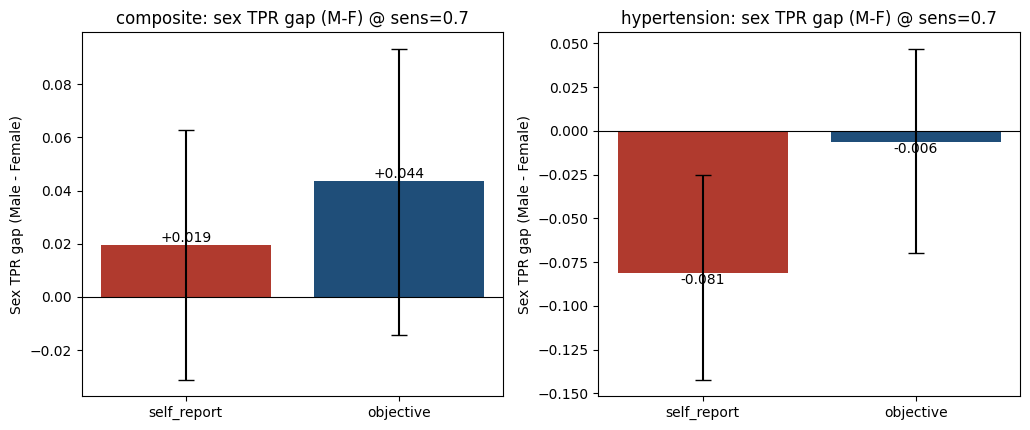

In [10]:
import matplotlib.pyplot as plt, csv

rows = []
for t, r in results.items():
    for inst in ('self_report', 'objective'):
        d = r[inst]
        rows.append(dict(target=t, instrument=inst, auc=round(d['auc'],4), prevalence=round(d['prev'],4),
                         tpr_female=round(d['tpr_f'],4), tpr_male=round(d['tpr_m'],4),
                         sex_gap=round(d['gap'],4), ci_low=round(d['ci'][0],4), ci_high=round(d['ci'][1],4)))
    rows.append(dict(target=t, instrument='CHANGE(obj-sr)', auc='', prevalence='', tpr_female='', tpr_male='',
                     sex_gap=round(r['change']['point'],4), ci_low=round(r['change']['ci'][0],4),
                     ci_high=round(r['change']['ci'][1],4)))

csv_path = os.path.join(TAB_DIR, 'nhanes_instrument_probe.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print('saved', csv_path)

fig, axes = plt.subplots(1, len(results), figsize=(5.2*len(results), 4.4), squeeze=False)
for ax, (t, r) in zip(axes[0], results.items()):
    insts = ['self_report', 'objective']
    gaps  = [r[i]['gap'] for i in insts]
    errs  = [[r[i]['gap']-r[i]['ci'][0] for i in insts], [r[i]['ci'][1]-r[i]['gap'] for i in insts]]
    ax.bar(insts, gaps, yerr=errs, capsize=6, color=['#B03A2E', '#1F4E79'])
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{t}: sex TPR gap (M-F) @ sens={TARGET_SENSITIVITY}')
    ax.set_ylabel('Sex TPR gap (Male - Female)')
    for i, g in enumerate(gaps):
        ax.text(i, g, f'{g:+.3f}', ha='center', va='bottom' if g >= 0 else 'top')
fig.tight_layout()
fig_path = os.path.join(FIG_DIR, 'nhanes_instrument_probe.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight'); print('saved', fig_path); plt.show()


## 8. Verdict — GO / SOFT / NO-GO

In [11]:
def gate(auc_sr, auc_obj):
    return min(auc_sr, auc_obj) >= 0.60

print('='*66)
for t, r in results.items():
    sr, ob, ch = r['self_report'], r['objective'], r['change']
    pt, (lo, hi) = ch['point'], ch['ci']
    shrinks   = pt < 0                 # objective gap smaller than self-report gap
    significant = hi < 0               # paired change CI excludes zero
    reliable  = gate(sr['auc'], ob['auc'])
    verdict = ('GO'   if (shrinks and significant and reliable) else
               'SOFT' if (shrinks and reliable) else
               'NO-GO')
    print(f'[{t}]  self-report gap {sr["gap"]:+.3f}  ->  objective gap {ob["gap"]:+.3f}   '
          f'change {pt:+.3f} [{lo:+.3f}, {hi:+.3f}]')
    print(f'       model AUCs {sr["auc"]:.3f}/{ob["auc"]:.3f} (reliable={reliable})  =>  **{verdict}**')
    print('-'*66)

print('Read: GO on the composite (or hypertension) means the sex gap is instrument-dependent on a '
      'confound-free population -> build the full method. SOFT = right direction but underpowered '
      '(try the 2017-2018 auscultatory-BP cycle or widen the composite). NO-GO on both = stop and '
      'submit EXHEART as it stands.')


[composite]  self-report gap +0.019  ->  objective gap +0.044   change +0.024 [-0.029, +0.074]
       model AUCs 0.824/0.733 (reliable=True)  =>  **NO-GO**
------------------------------------------------------------------
[hypertension]  self-report gap -0.081  ->  objective gap -0.006   change +0.075 [+0.001, +0.144]
       model AUCs 0.811/0.710 (reliable=True)  =>  **NO-GO**
------------------------------------------------------------------
Read: GO on the composite (or hypertension) means the sex gap is instrument-dependent on a confound-free population -> build the full method. SOFT = right direction but underpowered (try the 2017-2018 auscultatory-BP cycle or widen the composite). NO-GO on both = stop and submit EXHEART as it stands.


## 9. Save + commit + push

In [12]:
%cd {REPO_DIR}
!git add -A
!git -c user.name="Md Anas Biswas" -c user.email="anasbiswas@gmail.com" commit -m "EXHEART_16: NHANES paired-instrument go/no-go probe (self-report vs objective sex TPR-gap, same population, matched-sensitivity)"
!git push origin main
print('committed + pushed. Save this notebook to notebooks/EXHEART_16_nhanes_instrument_probe.ipynb via the Drive UI before closing.')


/content/drive/MyDrive/EXHEART_Research/exheart-research
[main 87dfcfd] EXHEART_16: NHANES paired-instrument go/no-go probe (self-report vs objective sex TPR-gap, same population, matched-sensitivity)
 40 files changed, 304574 insertions(+), 7 deletions(-)
 create mode 100644 data/brfss2015/heart_disease_health_indicators_BRFSS2015.csv
 create mode 100644 data/nhanes/P_BMX.XPT
 create mode 100644 data/nhanes/P_BPQ.XPT
 create mode 100644 data/nhanes/P_BPXO.XPT
 create mode 100644 data/nhanes/P_DEMO.XPT
 create mode 100644 data/nhanes/P_DIQ.XPT
 create mode 100644 data/nhanes/P_GHB.XPT
 create mode 100644 data/nhanes/P_SMQ.XPT
 create mode 100644 data/nhanes/P_TCHOL.XPT
 create mode 100644 exheart_results.zip
 rewrite notebooks/EXHEART_01_BRFSS2015.ipynb (79%)
 rewrite notebooks/EXHEART_02_BRFSS2020.ipynb (93%)
 rewrite notebooks/EXHEART_03_Cardio.ipynb (89%)
 rewrite notebooks/EXHEART_04_CrossDataset.ipynb (80%)
 create mode 100644 notebooks/EXHEART_06_shared_feature_transport.ipynb
 c

In [13]:
# === Step 1: cross-seed robustness of the hypertension instrument effect ===
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb, lightgbm as lgb, numpy as np, os, csv

SEEDS = [0, 1, 7, 13, 21, 42, 77, 101, 202, 2024]
TARGET = 'hypertension'
ROBUST_USE_MLP = False      # True = faithful full stack (slow); False = trees-only ranking check (fast)

def stack_seeded(Xtr, ytr, Xte, seed):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    learners = ['xgb','lgb','rf'] + (['mlp'] if ROBUST_USE_MLP else [])
    oof = {k: np.zeros(len(Xtr)) for k in learners}; tep = {k: np.zeros(len(Xte)) for k in learners}
    spw = (ytr==0).sum()/max((ytr==1).sum(),1)
    for fi,(tr,va) in enumerate(skf.split(Xtr,ytr)):
        Xt,Xv,yt = Xtr[tr],Xtr[va],ytr[tr]
        mx=xgb.XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,scale_pos_weight=spw,
                             subsample=0.8,colsample_bytree=0.8,eval_metric='auc',random_state=seed+fi,n_jobs=-1)
        mx.fit(Xt,yt); oof['xgb'][va]=mx.predict_proba(Xv)[:,1]; tep['xgb']+=mx.predict_proba(Xte)[:,1]/5
        ml=lgb.LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,class_weight='balanced',
                              subsample=0.8,colsample_bytree=0.8,random_state=seed+fi,n_jobs=-1,verbose=-1)
        ml.fit(Xt,yt); oof['lgb'][va]=ml.predict_proba(Xv)[:,1]; tep['lgb']+=ml.predict_proba(Xte)[:,1]/5
        mr=RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced',random_state=seed+fi,n_jobs=-1)
        mr.fit(Xt,yt); oof['rf'][va]=mr.predict_proba(Xv)[:,1]; tep['rf']+=mr.predict_proba(Xte)[:,1]/5
        if ROBUST_USE_MLP:
            from tensorflow.keras import callbacks
            es=callbacks.EarlyStopping(monitor='val_auc',mode='max',patience=5,restore_best_weights=True)
            mm=build_mlp(Xt.shape[1]); mm.fit(Xt,yt,validation_data=(Xv,ytr[va]),epochs=100,batch_size=256,callbacks=[es],verbose=0)
            oof['mlp'][va]=mm.predict(Xv,verbose=0).ravel(); tep['mlp']+=mm.predict(Xte,verbose=0).ravel()/5
    Z=np.column_stack([oof[k] for k in learners]); Zte=np.column_stack([tep[k] for k in learners])
    meta=LogisticRegression(class_weight='balanced',max_iter=1000).fit(Z,ytr)
    return meta.predict_proba(Zte)[:,1]

def gap_at_sens(y,p,sex,s):
    thr=sens_threshold(y,p,s); return tpr(y,p,thr,sex==1)-tpr(y,p,thr,sex==0)

sr_lab, obj_lab = targets[TARGET]
common = sr_lab.notna() & obj_lab.notna() & df[FEATURES].notna().any(axis=1)
idx = df.index[common]

rows=[]
for s in SEEDS:
    tr,te = train_test_split(idx, test_size=0.30, random_state=s, stratify=df.loc[idx,'SEX'].values)
    imp=SimpleImputer(strategy='median').fit(df.loc[tr,FEATURES]); scl=StandardScaler().fit(imp.transform(df.loc[tr,FEATURES]))
    MX=lambda ix: scl.transform(imp.transform(df.loc[ix,FEATURES]))
    Xtr,Xte=MX(tr),MX(te); sex_te=df.loc[te,'SEX'].values
    g={}
    for inst,lab in [('sr',sr_lab),('obj',obj_lab)]:
        ytr=lab.loc[tr].astype(int).values; yte=lab.loc[te].astype(int).values
        p=stack_seeded(Xtr,ytr,Xte,s); g[inst]=gap_at_sens(yte,p,sex_te,TARGET_SENSITIVITY); g[inst+'auc']=roc_auc_score(yte,p)
    collapse=abs(g['sr'])-abs(g['obj'])
    rows.append([s,round(g['sr'],4),round(g['obj'],4),round(collapse,4),round(g['srauc'],4),round(g['objauc'],4)])
    print(f'seed {s:>4} | sr gap {g["sr"]:+.3f} | obj gap {g["obj"]:+.3f} | collapse |sr|-|obj| {collapse:+.3f} | AUC {g["srauc"]:.3f}/{g["objauc"]:.3f}')

col=np.array([r[3] for r in rows]); srg=np.array([r[1] for r in rows]); objg=np.array([r[2] for r in rows])
print(f'\n=== across {len(SEEDS)} seeds (MLP={ROBUST_USE_MLP}) ===')
print('self-report |gap| : mean %.3f (min %.3f)'%(np.abs(srg).mean(),np.abs(srg).min()))
print('objective   |gap| : mean %.3f (max %.3f)'%(np.abs(objg).mean(),np.abs(objg).max()))
print('collapse |sr|-|obj|: mean %+.3f (min %+.3f, max %+.3f) | positive in %d/%d seeds'%(col.mean(),col.min(),col.max(),(col>0).sum(),len(col)))
robust=(col>0).mean()>=0.8 and col.mean()>0.03
print('VERDICT:', 'ROBUST GO' if robust else 'FRAGILE', '— objective gap %s smaller in magnitude'%('consistently' if robust else 'not consistently'))

out=os.path.join(TAB_DIR,'nhanes_hypertension_seed_robustness.csv')
with open(out,'w',newline='') as f:
    w=csv.writer(f); w.writerow(['seed','sr_gap','obj_gap','collapse','sr_auc','obj_auc']); w.writerows(rows)
print('saved',out)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed    0 | sr gap -0.079 | obj gap +0.052 | collapse |sr|-|obj| +0.027 | AUC 0.791/0.717


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed    1 | sr gap -0.018 | obj gap +0.054 | collapse |sr|-|obj| -0.035 | AUC 0.800/0.705


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

...

seed  101 | sr gap -0.078 | obj gap +0.018 | collapse |sr|-|obj| +0.060 | AUC 0.811/0.706


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed  202 | sr gap -0.056 | obj gap -0.004 | collapse |sr|-|obj| +0.052 | AUC 0.796/0.699


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed 2024 | sr gap -0.056 | obj gap +0.017 | collapse |sr|-|obj| +0.040 | AUC 0.791/0.707

=== across 10 seeds (MLP=False) ===
self-report |gap| : mean 0.057 (min 0.018)
objective   |gap| : mean 0.025 (max 0.053)
collapse |sr|-|obj|: mean +0.032 (min -0.035, max +0.062) | positive in 9/10 seeds
VERDICT: ROBUST GO — objective gap consistently smaller in magnitude
saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/nhanes_hypertension_seed_robustness.csv


In [14]:
# === Step 2: DIF + sex-specific misclassification + E-value on the hypertension arm ===
import numpy as np, pandas as pd, os, csv
import statsmodels.api as sm
from scipy import stats

# paired frame: same people, self-report vs measured hypertension, with sex + covariates
sr  = sr_htn.copy()                 # self-reported hypertension (BPQ020): 1/0/NaN
obj = obj_htn.copy()                # measured hypertension (BPXO >= 130/80): 1/0/NaN
m   = sr.notna() & obj.notna() & df['AGE'].notna() & df['BMI'].notna()
d   = pd.DataFrame({
        'sr': sr[m].astype(int), 'obj': obj[m].astype(int),
        'male': df.loc[m,'SEX'].astype(int),          # 1 = male, 0 = female
        'age': df.loc[m,'AGE'].astype(float),
        'bmi': df.loc[m,'BMI'].astype(float),
     }).dropna()
print(f'paired n = {len(d)} | female {(d.male==0).sum()} | male {(d.male==1).sum()}')

# ---------- 1. DIF: does self-report differ by sex given TRUE (measured) status + severity ----------
# logistic: P(self-report=1) ~ measured status (anchor) + sex + age + bmi
# a significant 'male' coefficient conditional on measured truth = uniform DIF (differential reporting).
X = sm.add_constant(d[['obj','male','age','bmi']].astype(float))
dif = sm.Logit(d['sr'], X).fit(disp=0)
b_male, se_male = dif.params['male'], dif.bse['male']
p_male = dif.pvalues['male']; or_male = np.exp(b_male); or_ci = np.exp([b_male-1.96*se_male, b_male+1.96*se_male])
# non-uniform DIF: does the sex effect vary with true status? add interaction
d['obj_male'] = d['obj']*d['male']
Xi = sm.add_constant(d[['obj','male','obj_male','age','bmi']].astype(float))
dif_i = sm.Logit(d['sr'], Xi).fit(disp=0)
p_inter = dif_i.pvalues['obj_male']
print('\n--- DIF (self-report ~ measured-truth + sex + age + bmi) ---')
print(f'uniform DIF (sex | true status): OR {or_male:.3f} [{or_ci[0]:.3f}, {or_ci[1]:.3f}], p = {p_male:.4g}')
print(f'  interpretation: OR<1 => men LESS likely to self-report hypertension than women at the same measured BP')
print(f'non-uniform DIF (sex x true-status interaction): p = {p_inter:.4g}')

# ---------- 2. sex-specific misclassification of self-report vs measured truth ----------
def sens_spec(sub):
    tp = ((sub.sr==1)&(sub.obj==1)).sum(); fn = ((sub.sr==0)&(sub.obj==1)).sum()
    tn = ((sub.sr==0)&(sub.obj==0)).sum(); fp = ((sub.sr==1)&(sub.obj==0)).sum()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    spec = tn/(tn+fp) if (tn+fp) else np.nan
    return sens, spec, tp+fn, tn+fp
rows=[]
for lab,val in [('Female',0),('Male',1)]:
    se,sp,npos,nneg = sens_spec(d[d.male==val])
    rows.append([lab, round(se,4), round(sp,4), int(npos), int(nneg)])
    print(f'\n{lab}: self-report sensitivity {se:.3f} (n_true+={npos}) | specificity {sp:.3f} (n_true-={nneg})')
# test whether self-report sensitivity differs by sex (chi-square on the true-positive stratum)
tp_f=((d.male==0)&(d.sr==1)&(d.obj==1)).sum(); fn_f=((d.male==0)&(d.sr==0)&(d.obj==1)).sum()
tp_m=((d.male==1)&(d.sr==1)&(d.obj==1)).sum(); fn_m=((d.male==1)&(d.sr==0)&(d.obj==1)).sum()
chi2,pchi,_,_ = stats.chi2_contingency([[tp_f,fn_f],[tp_m,fn_m]])
print(f'\nsex difference in self-report sensitivity among truly hypertensive: chi2={chi2:.2f}, p={pchi:.4g}')

# ---------- 3. E-value on the instrument effect (gap magnitude collapse) ----------
# frame the effect as a risk ratio: self-report vs objective |gap| from the seed-robustness table
srb = pd.read_csv(os.path.join(TAB_DIR,'nhanes_hypertension_seed_robustness.csv'))
rr = np.abs(srb.sr_gap).mean() / max(np.abs(srb.obj_gap).mean(), 1e-6)
def evalue(rr):
    rr = rr if rr>=1 else 1/rr
    return rr + np.sqrt(rr*(rr-1))
ev = evalue(rr)
print(f'\n--- E-value ---')
print(f'gap magnitude ratio (self-report / objective) = {rr:.2f}  =>  E-value = {ev:.2f}')
print(f'  an unmeasured confounder would need associations of RR>={ev:.2f} with both instrument and gap to explain it away')

# ---------- save ----------
with open(os.path.join(TAB_DIR,'step2_dif_misclassification.csv'),'w',newline='') as f:
    w=csv.writer(f)
    w.writerow(['metric','value'])
    w.writerow(['dif_uniform_OR_male',round(or_male,4)]); w.writerow(['dif_uniform_p',p_male])
    w.writerow(['dif_nonuniform_p',p_inter]); w.writerow(['sens_sex_diff_p',pchi])
    w.writerow(['gap_ratio_sr_over_obj',round(rr,3)]); w.writerow(['evalue',round(ev,3)])
    w.writerow([]); w.writerow(['sex','sensitivity','specificity','n_true_pos','n_true_neg'])
    for r in rows: w.writerow(r)
print('\nsaved', os.path.join(TAB_DIR,'step2_dif_misclassification.csv'))

paired n = 7934 | female 4010 | male 3924

--- DIF (self-report ~ measured-truth + sex + age + bmi) ---
uniform DIF (sex | true status): OR 1.050 [0.944, 1.169], p = 0.3651
  interpretation: OR<1 => men LESS likely to self-report hypertension than women at the same measured BP
non-uniform DIF (sex x true-status interaction): p = 0.007879

Female: self-report sensitivity 0.580 (n_true+=1572) | specificity 0.771 (n_true-=2438)

Male: self-report sensitivity 0.501 (n_true+=1781) | specificity 0.730 (n_true-=2143)

sex difference in self-report sensitivity among truly hypertensive: chi2=20.52, p=5.903e-06

--- E-value ---
gap magnitude ratio (self-report / objective) = 2.26  =>  E-value = 3.95
  an unmeasured confounder would need associations of RR>=3.95 with both instrument and gap to explain it away

saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/step2_dif_misclassification.csv


In [15]:
# === Step 3: inject the measured sex-differential self-report error into CLEAN labels ===
# If corrupting objective (measured) labels with the observed male/female sensitivity+specificity
# reproduces the self-report sex TPR gap, differential measurement reliability CAUSES the disparity.
import numpy as np, pandas as pd, os, csv
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

TARGET  = 'hypertension'
SEEDS3  = [0, 13, 42, 101, 202]          # trees-only ranking via stack_seeded (ROBUST_USE_MLP=False)
sr_lab, obj_lab = targets[TARGET]

# empirical sex-specific self-report error vs measured truth (same computation as Step 2)
mm = sr_lab.notna() & obj_lab.notna()
b  = pd.DataFrame({'sr': sr_lab[mm].astype(int), 'obj': obj_lab[mm].astype(int), 'male': df.loc[mm,'SEX'].astype(int)})
def ss(sub):
    tp=((sub.sr==1)&(sub.obj==1)).sum(); fn=((sub.sr==0)&(sub.obj==1)).sum()
    tn=((sub.sr==0)&(sub.obj==0)).sum(); fp=((sub.sr==1)&(sub.obj==0)).sum()
    return tp/(tp+fn), tn/(tn+fp)
sens_f,spec_f = ss(b[b.male==0]); sens_m,spec_m = ss(b[b.male==1])
print(f'empirical error | female sens {sens_f:.3f} spec {spec_f:.3f} | male sens {sens_m:.3f} spec {spec_m:.3f}')

def corrupt(y, sex, seed):
    rng = np.random.default_rng(1000+seed); out = y.copy().astype(int)
    for val,(se,sp) in [(0,(sens_f,spec_f)),(1,(sens_m,spec_m))]:
        idx = np.where(sex==val)[0]; pos = idx[y[idx]==1]; neg = idx[y[idx]==0]
        out[pos[rng.random(len(pos)) > se]] = 0     # truly hypertensive but fails to report
        out[neg[rng.random(len(neg)) > sp]] = 1     # truly non-hypertensive but falsely reports
    return out

def gap_at_sens(y,p,sex,s):
    thr=sens_threshold(y,p,s); return tpr(y,p,thr,sex==1)-tpr(y,p,thr,sex==0)

common = sr_lab.notna() & obj_lab.notna() & df[FEATURES].notna().any(axis=1)
idx = df.index[common]; sex_all = df.loc[idx,'SEX'].astype(int).values

rows=[]
for s in SEEDS3:
    tr,te = train_test_split(idx, test_size=0.30, random_state=s, stratify=df.loc[idx,'SEX'].values)
    imp=SimpleImputer(strategy='median').fit(df.loc[tr,FEATURES]); scl=StandardScaler().fit(imp.transform(df.loc[tr,FEATURES]))
    MX=lambda ix: scl.transform(imp.transform(df.loc[ix,FEATURES])); Xtr,Xte=MX(tr),MX(te)
    sex_te = df.loc[te,'SEX'].astype(int).values
    y_corr = pd.Series(corrupt(obj_lab.loc[idx].astype(int).values, sex_all, s), index=idx)
    g={}
    p=stack_seeded(Xtr, obj_lab.loc[tr].astype(int).values, Xte, s); g['obj']=gap_at_sens(obj_lab.loc[te].astype(int).values,p,sex_te,TARGET_SENSITIVITY)
    p=stack_seeded(Xtr, y_corr.loc[tr].values,                 Xte, s); g['inj']=gap_at_sens(y_corr.loc[te].values,               p,sex_te,TARGET_SENSITIVITY)
    p=stack_seeded(Xtr, sr_lab.loc[tr].astype(int).values,     Xte, s); g['sr'] =gap_at_sens(sr_lab.loc[te].astype(int).values,    p,sex_te,TARGET_SENSITIVITY)
    rows.append([s,round(g['obj'],4),round(g['inj'],4),round(g['sr'],4)])
    print(f'seed {s:>4} | objective {g["obj"]:+.3f} | injected {g["inj"]:+.3f} | self-report {g["sr"]:+.3f}')

R=np.array([r[1:] for r in rows])
print(f'\n=== mean over {len(SEEDS3)} seeds ===')
print(f'objective    {R[:,0].mean():+.3f}   (clean measured labels)')
print(f'injected     {R[:,1].mean():+.3f}   (clean + measured sex-differential error)')
print(f'self-report  {R[:,2].mean():+.3f}   (actual)')
rec = R[:,1].mean()/R[:,2].mean() if R[:,2].mean() else float('nan')
match = np.sign(R[:,1].mean())==np.sign(R[:,2].mean()) and abs(R[:,1].mean())>abs(R[:,0].mean())+0.01
print(f'\ninjection reproduces {rec*100:.0f}% of the self-report gap; objective stays ~null')
print('VERDICT:', 'MECHANISM CONFIRMED' if match else 'injection did not reproduce the gap')

with open(os.path.join(TAB_DIR,'step3_label_injection.csv'),'w',newline='') as f:
    w=csv.writer(f); w.writerow(['seed','gap_objective','gap_injected','gap_self_report']); w.writerows(rows)
    w.writerow([]); w.writerow(['sens_female',sens_f,'spec_female',spec_f,'sens_male',sens_m,'spec_male',spec_m])
print('saved', os.path.join(TAB_DIR,'step3_label_injection.csv'))

empirical error | female sens 0.582 spec 0.771 | male sens 0.501 spec 0.729


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed    0 | objective +0.052 | injected -0.019 | self-report -0.079


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed   13 | objective +0.048 | injected +0.050 | self-report -0.082


...

seed   42 | objective -0.010 | injected -0.047 | self-report -0.072


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed  101 | objective +0.018 | injected -0.038 | self-report -0.078


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

seed  202 | objective -0.004 | injected +0.005 | self-report -0.056

=== mean over 5 seeds ===
objective    +0.021   (clean measured labels)
injected     -0.010   (clean + measured sex-differential error)
self-report  -0.073   (actual)

injection reproduces 13% of the self-report gap; objective stays ~null
VERDICT: injection did not reproduce the gap
saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/step3_label_injection.csv


In [16]:
# === Descriptive: does the feature->report map differ by sex among the truly hypertensive? ===
import numpy as np, pandas as pd, os, csv
import statsmodels.api as sm

# restrict to people who ARE hypertensive by measured BP (the stratum where under-reporting bites detection)
sr  = sr_htn.copy(); obj = obj_htn.copy()
m   = sr.notna() & (obj==1) & df[['AGE','BMI','PIR','RACE']].notna().all(axis=1)
d   = pd.DataFrame({
        'report': sr[m].astype(int),                 # among truly hypertensive: did they self-report it
        'male'  : df.loc[m,'SEX'].astype(int),
        'age'   : df.loc[m,'AGE'].astype(float),
        'bmi'   : df.loc[m,'BMI'].astype(float),
        'pir'   : df.loc[m,'PIR'].astype(float),
     }).dropna()
Z = ['age','bmi','pir']
print(f'truly-hypertensive n = {len(d)} | female {(d.male==0).sum()} | male {(d.male==1).sum()}')
print(f'raw report rate | female {d.report[d.male==0].mean():.3f} | male {d.report[d.male==1].mean():.3f}')

# ---- 1. formal test: do feature slopes differ by sex? pooled model with sex x feature interactions ----
dz = d.copy()
for c in Z: dz[c] = (dz[c]-dz[c].mean())/dz[c].std()      # standardize for interpretable interactions
dz['const']=1.0
main  = ['const','male']+Z
inter = [f'{c}_x_male' for c in Z]
for c in Z: dz[f'{c}_x_male']=dz[c]*dz['male']
full   = sm.Logit(dz['report'], dz[main+inter]).fit(disp=0)
reduced= sm.Logit(dz['report'], dz[main]).fit(disp=0)
LR = 2*(full.llf-reduced.llf); from scipy.stats import chi2; p_lr = chi2.sf(LR, len(inter))
print(f'\n--- do feature slopes differ by sex? (LR test on all sex x feature interactions) ---')
print(f'LR chi2 = {LR:.2f}, df = {len(inter)}, p = {p_lr:.4g}')
for c in Z:
    b=full.params[f'{c}_x_male']; se=full.bse[f'{c}_x_male']; p=full.pvalues[f'{c}_x_male']
    print(f'  {c:>4}: sex-interaction beta {b:+.3f} [{b-1.96*se:+.3f}, {b+1.96*se:+.3f}], p={p:.4g}')

# ---- 2. sex-separate slopes, side by side (the descriptive picture) ----
rows=[]
print(f'\n--- feature->report slopes fit separately (standardized logits) ---')
for lab,val in [('Female',0),('Male',1)]:
    sub=dz[dz.male==val]
    fit=sm.Logit(sub['report'], sub[['const']+Z]).fit(disp=0)
    print(f'  {lab}:', ' | '.join(f'{c} {fit.params[c]:+.3f}' for c in Z))
    for c in Z: rows.append([lab,c,round(fit.params[c],4),round(fit.bse[c],4),round(fit.pvalues[c],4)])

with open(os.path.join(TAB_DIR,'step3b_feature_report_by_sex.csv'),'w',newline='') as f:
    w=csv.writer(f); w.writerow(['LR_chi2',round(LR,3),'df',len(inter),'p',p_lr])
    w.writerow(['sex','feature','slope','se','p']); w.writerows(rows)
print('\nsaved', os.path.join(TAB_DIR,'step3b_feature_report_by_sex.csv'))
print('READ: small LR p => the feature->report map differs by sex, i.e. WHICH people under-report is feature-structured differently for men and women. That is the feature-entangled reporting the injection null implied.')

truly-hypertensive n = 2903 | female 1364 | male 1539
raw report rate | female 0.581 | male 0.506

--- do feature slopes differ by sex? (LR test on all sex x feature interactions) ---
LR chi2 = 15.49, df = 3, p = 0.00144
   age: sex-interaction beta -0.185 [-0.356, -0.014], p=0.03399
   bmi: sex-interaction beta +0.124 [-0.046, +0.294], p=0.1524
   pir: sex-interaction beta +0.218 [+0.062, +0.373], p=0.006035

--- feature->report slopes fit separately (standardized logits) ---
  Female: age +0.774 | bmi +0.322 | pir -0.246
  Male: age +0.589 | bmi +0.446 | pir -0.028

saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/step3b_feature_report_by_sex.csv
READ: small LR p => the feature->report map differs by sex, i.e. WHICH people under-report is feature-structured differently for men and women. That is the feature-entangled reporting the injection null implied.


In [17]:
# === Broadening: label-provenance disparity across constructs x demographics ===
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd, os, csv

BROAD_SEEDS = [0, 13, 42, 101, 202]
SENS = TARGET_SENSITIVITY

# ---- objective + self-report label pairs per construct ----
sbp = df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1); dbp = df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1)
def yn(s):
    o = pd.Series(np.nan, index=s.index); o[s==1]=1.0; o[s==2]=0.0; return o
constructs = {
    'hypertension': (yn(df['BPQ020']), (((sbp>=130)|(dbp>=80)).astype('float').mask(sbp.isna()&dbp.isna()))),
    'cholesterol' : (yn(df['BPQ080']), (df['LBXTC']>=240).astype('float').mask(df['LBXTC'].isna())),
    'diabetes'    : (yn(df['DIQ010']).where(df['DIQ010']!=3, 0.0), (df['LBXGH']>=6.5).astype('float').mask(df['LBXGH'].isna())),
}

# ---- demographic axes: build binary group contrasts ----
race = df['RIDRETH3']   # 1 MexAm,2 OthHisp,3 NHWhite,4 NHBlack,6 NHAsian,7 Other
groups = {
    'sex_M_vs_F'          : (df['SEX']==1).astype(float),                          # 1=male focal
    'race_Black_vs_White' : pd.Series(np.where(race==4,1.0,np.where(race==3,0.0,np.nan)), index=df.index),
    'race_Hisp_vs_White'  : pd.Series(np.where(race.isin([1,2]),1.0,np.where(race==3,0.0,np.nan)), index=df.index),
    'race_Asian_vs_White' : pd.Series(np.where(race==6,1.0,np.where(race==3,0.0,np.nan)), index=df.index),
    'income_low_vs_high'  : pd.Series(np.where(df['PIR']<1.3,1.0,np.where(df['PIR']>=3.0,0.0,np.nan)), index=df.index),
    'age_old_vs_young'    : pd.Series(np.where(df['AGE']>=60,1.0,np.where(df['AGE']<45,0.0,np.nan)), index=df.index),
}

def sens_thr(y,p,s):
    pos=np.sort(p[y==1]);
    return np.inf if len(pos)==0 else pos[min(max(int(np.floor((1-s)*len(pos))),0),len(pos)-1)]
def tpr_m(y,p,thr,mask):
    yy,pp=y[mask],p[mask]; d=(yy==1).sum(); return np.nan if d==0 else float(((pp>=thr)&(yy==1)).sum()/d)

def gap_for(labels, focal, seeds):
    """mean focal-vs-ref TPR gap under a given label set, across seeds, at matched sensitivity."""
    m = labels.notna() & focal.notna() & df[FEATURES].notna().any(axis=1)
    idx = df.index[m]; gg=[]
    if len(idx) < 400 or focal.loc[idx].nunique()<2: return np.nan, len(idx)
    for s in seeds:
        strat = focal.loc[idx].astype(int).values
        tr,te = train_test_split(idx, test_size=0.30, random_state=s, stratify=strat)
        imp=SimpleImputer(strategy='median').fit(df.loc[tr,FEATURES]); scl=StandardScaler().fit(imp.transform(df.loc[tr,FEATURES]))
        MX=lambda ix: scl.transform(imp.transform(df.loc[ix,FEATURES]))
        ytr=labels.loc[tr].astype(int).values; yte=labels.loc[te].astype(int).values
        p=stack_seeded(MX(tr),ytr,MX(te),s)
        thr=sens_thr(yte,p,SENS); fo=focal.loc[te].astype(int).values
        gg.append(tpr_m(yte,p,thr,fo==1)-tpr_m(yte,p,thr,fo==0))
    return float(np.nanmean(gg)), len(idx)

rows=[]
for cname,(sr_lab,obj_lab) in constructs.items():
    for gname,focal in groups.items():
        g_sr ,n_sr  = gap_for(sr_lab , focal, BROAD_SEEDS)
        g_obj,n_obj = gap_for(obj_lab, focal, BROAD_SEEDS)
        collapse = abs(g_sr)-abs(g_obj) if np.isfinite(g_sr) and np.isfinite(g_obj) else np.nan
        rows.append([cname,gname,round(g_sr,4) if np.isfinite(g_sr) else None,
                     round(g_obj,4) if np.isfinite(g_obj) else None,
                     round(collapse,4) if np.isfinite(collapse) else None, n_sr])
        tag = '' if not np.isfinite(collapse) else ('  <-- COLLAPSE' if collapse>0.02 else ('  (obj larger)' if collapse<-0.02 else '  (flat)'))
        print(f'{cname:12s} | {gname:22s} | sr {str(g_sr)[:6]:>6} | obj {str(g_obj)[:6]:>6} | |sr|-|obj| {str(collapse)[:6]:>6}{tag}')

grid = pd.DataFrame(rows, columns=['construct','group','sr_gap','obj_gap','collapse','n'])
fin  = grid.dropna(subset=['collapse'])
pos  = (fin.collapse>0.02).sum(); tot=len(fin)
print(f'\n=== phenomenon check ===')
print(f'cells with self-report gap collapsing under objective (>0.02): {pos}/{tot}')
print(f'mean collapse across all valid cells: {fin.collapse.mean():+.3f}')
print('by construct:'); print(fin.groupby('construct').collapse.mean().round(3).to_string())
print('by demographic axis:'); print(fin.groupby('group').collapse.mean().round(3).to_string())
strong = fin.reindex(fin.collapse.abs().sort_values(ascending=False).index).head(5)
print('\nstrongest effects (any direction):'); print(strong.to_string(index=False))

grid.to_csv(os.path.join(TAB_DIR,'broadening_construct_x_demographic.csv'), index=False)
print('\nsaved', os.path.join(TAB_DIR,'broadening_construct_x_demographic.csv'))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

hypertension | sex_M_vs_F             | sr -0.029 | obj 0.0269 | |sr|-|obj| 0.0024  (flat)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

hypertension | race_Black_vs_White    | sr 0.0924 | obj 0.2130 | |sr|-|obj| -0.120  (obj larger)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

...

diabetes     | race_Asian_vs_White    | sr -0.179 | obj -0.045 | |sr|-|obj| 0.1338  <-- COLLAPSE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

diabetes     | income_low_vs_high     | sr 0.1136 | obj 0.0100 | |sr|-|obj| 0.1036  <-- COLLAPSE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

diabetes     | age_old_vs_young       | sr 0.7354 | obj 0.7286 | |sr|-|obj| 0.0068  (flat)

=== phenomenon check ===
cells with self-report gap collapsing under objective (>0.02): 9/18
mean collapse across all valid cells: +0.072
by construct:
construct
cholesterol     0.124
diabetes        0.046
hypertension    0.047
by demographic axis:
group
age_old_vs_young       0.294
income_low_vs_high     0.017
race_Asian_vs_White    0.113
race_Black_vs_White   -0.024
race_Hisp_vs_White     0.073
sex_M_vs_F            -0.039

strongest effects (any direction):
   construct               group  sr_gap  obj_gap  collapse    n
 cholesterol    age_old_vs_young  0.8840   0.2844    0.5996 7361
hypertension    age_old_vs_young  0.8506   0.5740    0.2766 7405
 cholesterol race_Asian_vs_White -0.2217   0.0647    0.1570 4513
 cholesterol  race_Hisp_vs_White -0.1453  -0.0062    0.1391 5454
 cholesterol          sex_M_vs_F  0.0075  -0.1445   -0.1370 9627

saved /content/drive/MyDrive/EXHEART_Research/exhear

In [18]:
# === Age-collapse confound gate: is it reporting reliability, or prevalence x threshold? ===
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd, os, csv

GATE_SEEDS = [0, 13, 42, 101, 202]
sbp = df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1); dbp = df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1)
def yn(s):
    o = pd.Series(np.nan, index=s.index); o[s==1]=1.0; o[s==2]=0.0; return o
constructs = {
    'cholesterol' : (yn(df['BPQ080']), (df['LBXTC']>=240).astype('float').mask(df['LBXTC'].isna())),
    'hypertension': (yn(df['BPQ020']), (((sbp>=130)|(dbp>=80)).astype('float').mask(sbp.isna()&dbp.isna()))),
}

def thr_matched_sens(y,p,s):
    pos=np.sort(p[y==1]); return np.inf if len(pos)==0 else pos[min(max(int(np.floor((1-s)*len(pos))),0),len(pos)-1)]
def thr_prev_matched(y,p):                       # threshold so #flagged == #true-positives (prevalence-matched)
    k=int(round(y.sum()));
    return np.inf if k<=0 else np.sort(p)[::-1][min(k-1,len(p)-1)]
def tprf(y,p,thr,mask):
    yy,pp=y[mask],p[mask]; d=(yy==1).sum(); return np.nan if d==0 else float(((pp>=thr)&(yy==1)).sum()/d)

def run(labels, focal, seeds, rule):
    m=labels.notna()&focal.notna()&df[FEATURES].notna().any(axis=1); idx=df.index[m]
    if len(idx)<400 or focal.loc[idx].nunique()<2: return np.nan,np.nan,np.nan
    gg=[]; pf=[]; pr=[]
    for s in seeds:
        tr,te=train_test_split(idx,test_size=0.30,random_state=s,stratify=focal.loc[idx].astype(int).values)
        imp=SimpleImputer(strategy='median').fit(df.loc[tr,FEATURES]); scl=StandardScaler().fit(imp.transform(df.loc[tr,FEATURES]))
        MX=lambda ix: scl.transform(imp.transform(df.loc[ix,FEATURES]))
        ytr=labels.loc[tr].astype(int).values; yte=labels.loc[te].astype(int).values
        p=stack_seeded(MX(tr),ytr,MX(te),s); fo=focal.loc[te].astype(int).values
        thr = thr_matched_sens(yte,p,TARGET_SENSITIVITY) if rule=='sens' else thr_prev_matched(yte,p)
        gg.append(tprf(yte,p,thr,fo==1)-tprf(yte,p,thr,fo==0))
        pf.append(yte[fo==1].mean()); pr.append(yte[fo==0].mean())      # objective base rates per group
    return float(np.nanmean(gg)), float(np.nanmean(pf)), float(np.nanmean(pr))

age_full   = pd.Series(np.where(df['AGE']>=60,1.0,np.where(df['AGE']<45,0.0,np.nan)), index=df.index)
age_narrow = pd.Series(np.where((df['AGE']>=60)&(df['AGE']<=70),1.0,
                        np.where((df['AGE']>=50)&(df['AGE']<60),0.0,np.nan)), index=df.index)

rows=[]
for cname,(sr,obj) in constructs.items():
    for aname,focal in [('age_full_60+_vs_<45',age_full),('age_narrow_60-70_vs_50-59',age_narrow)]:
        for rule in ['sens','prev']:
            g_sr ,bf_sr ,br_sr  = run(sr , focal, GATE_SEEDS, rule)
            g_obj,bf_obj,br_obj = run(obj, focal, GATE_SEEDS, rule)
            coll = abs(g_sr)-abs(g_obj) if np.isfinite(g_sr) and np.isfinite(g_obj) else np.nan
            rows.append([cname,aname,rule,round(g_sr,3),round(g_obj,3),round(coll,3),
                         round(bf_obj,3),round(br_obj,3)])
            print(f'{cname:12s}|{aname:26s}|{rule:4s}| sr {g_sr:+.3f} obj {g_obj:+.3f} | collapse {coll:+.3f} '
                  f'| obj prev old {bf_obj:.2f} young {br_obj:.2f} (gap {bf_obj-br_obj:+.2f})')

print('\n=== verdict ===')
grid=pd.DataFrame(rows,columns=['construct','age_contrast','rule','sr_gap','obj_gap','collapse','obj_prev_old','obj_prev_young'])
narrow=grid[grid.age_contrast.str.contains('narrow')]
print('NARROW-BAND collapse (small prevalence gap => reporting-reliability, not prevalence):')
print(narrow[['construct','rule','collapse','obj_prev_old','obj_prev_young']].to_string(index=False))
holds = (narrow.collapse>0.05).mean()
print(f'\nnarrow-band collapse survives (>0.05) in {(narrow.collapse>0.05).sum()}/{len(narrow)} cells')
print('VERDICT:', 'AGE EFFECT IS REAL (survives narrow-band + prevalence-matched)' if holds>=0.5
      else 'AGE EFFECT IS LARGELY PREVALENCE x THRESHOLD ARTIFACT')
grid.to_csv(os.path.join(TAB_DIR,'age_confound_gate.csv'),index=False)
print('saved', os.path.join(TAB_DIR,'age_confound_gate.csv'))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

cholesterol |age_full_60+_vs_<45       |sens| sr +0.884 obj +0.284 | collapse +0.600 | obj prev old 0.10 young 0.06 (gap +0.04)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

cholesterol |age_full_60+_vs_<45       |prev| sr +0.733 obj +0.246 | collapse +0.487 | obj prev old 0.10 young 0.06 (gap +0.04)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

...

hypertension|age_full_60+_vs_<45       |prev| sr +0.831 obj +0.573 | collapse +0.258 | obj prev old 0.58 young 0.25 (gap +0.33)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

hypertension|age_narrow_60-70_vs_50-59 |sens| sr +0.287 obj +0.086 | collapse +0.202 | obj prev old 0.55 young 0.51 (gap +0.03)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

hypertension|age_narrow_60-70_vs_50-59 |prev| sr +0.304 obj +0.068 | collapse +0.236 | obj prev old 0.55 young 0.51 (gap +0.03)

=== verdict ===
NARROW-BAND collapse (small prevalence gap => reporting-reliability, not prevalence):
   construct rule  collapse  obj_prev_old  obj_prev_young
 cholesterol sens     0.268         0.099           0.157
 cholesterol prev     0.381         0.099           0.157
hypertension sens     0.202         0.549           0.515
hypertension prev     0.236         0.549           0.515

narrow-band collapse survives (>0.05) in 4/4 cells
VERDICT: AGE EFFECT IS REAL (survives narrow-band + prevalence-matched)
saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/age_confound_gate.csv


In [19]:
# === Step 2 (AGE arm): differential self-report reliability by age + DIF + E-value ===
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os, csv
import statsmodels.api as sm
from scipy import stats

def _yn(s):
    o = pd.Series(np.nan, index=s.index); o[s==1]=1.0; o[s==2]=0.0; return o
sbp = df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1); dbp = df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1)
CON = {'cholesterol':(_yn(df['BPQ080']), (df['LBXTC']>=240).astype('float').mask(df['LBXTC'].isna())),
       'hypertension':(_yn(df['BPQ020']), (((sbp>=130)|(dbp>=80)).astype('float').mask(sbp.isna()&dbp.isna())))}
AGE_N = pd.Series(np.where((df['AGE']>=60)&(df['AGE']<=70),1.0,np.where((df['AGE']>=50)&(df['AGE']<60),0.0,np.nan)),index=df.index)
AGE_F = pd.Series(np.where(df['AGE']>=60,1.0,np.where(df['AGE']<45,0.0,np.nan)),index=df.index)

def ss(sub):
    tp=((sub.sr==1)&(sub.obj==1)).sum(); fn=((sub.sr==0)&(sub.obj==1)).sum()
    tn=((sub.sr==0)&(sub.obj==0)).sum(); fp=((sub.sr==1)&(sub.obj==0)).sum()
    return (tp/(tp+fn) if (tp+fn) else np.nan),(tn/(tn+fp) if (tn+fp) else np.nan),int(tp+fn),int(tn+fp)

rows=[]
for cname,(sr,obj) in CON.items():
    for aname,age in [('narrow_60-70_vs_50-59',AGE_N),('full_60+_vs_<45',AGE_F)]:
        m = sr.notna()&obj.notna()&age.notna()&df['BMI'].notna()
        d = pd.DataFrame({'sr':sr[m].astype(int),'obj':obj[m].astype(int),'old':age[m].astype(int),
                          'bmi':df.loc[m,'BMI'].astype(float),'sex':df.loc[m,'SEX'].astype(int)}).dropna()
        se_o,sp_o,no,_ = ss(d[d.old==1]); se_y,sp_y,ny,_ = ss(d[d.old==0])
        tp_o=((d.old==1)&(d.sr==1)&(d.obj==1)).sum(); fn_o=((d.old==1)&(d.sr==0)&(d.obj==1)).sum()
        tp_y=((d.old==0)&(d.sr==1)&(d.obj==1)).sum(); fn_y=((d.old==0)&(d.sr==0)&(d.obj==1)).sum()
        chi2s,pchi,_,_ = stats.chi2_contingency([[tp_o,fn_o],[tp_y,fn_y]])
        try:
            du = sm.Logit(d['sr'], sm.add_constant(d[['obj','old','bmi','sex']].astype(float))).fit(disp=0)
            or_old=float(np.exp(du.params['old'])); p_old=float(du.pvalues['old'])
            d2=d.copy(); d2['obj_old']=d2['obj']*d2['old']
            di = sm.Logit(d2['sr'], sm.add_constant(d2[['obj','old','obj_old','bmi','sex']].astype(float))).fit(disp=0)
            p_int=float(di.pvalues['obj_old'])
        except Exception as e:
            or_old=p_old=p_int=float('nan'); print('  DIF fit failed:',type(e).__name__)
        print(f'{cname:11s}|{aname:22s}| old sens {se_o:.3f} spec {sp_o:.3f} (n+={no}) | young sens {se_y:.3f} spec {sp_y:.3f} (n+={ny})')
        print(f'{"":34s}| sens-diff chi2 p={pchi:.3g} | uniform DIF OR_old {or_old:.2f} p={p_old:.3g} | non-uniform DIF p={p_int:.3g}')
        rows.append([cname,aname,round(se_o,4),round(sp_o,4),round(se_y,4),round(sp_y,4),no,ny,round(pchi,6),round(or_old,4),round(p_old,6),round(p_int,6)])

gate = pd.read_csv(os.path.join(TAB_DIR,'age_confound_gate.csv'))
gn = gate[gate.age_contrast.str.contains('narrow')]
rr = gn.sr_gap.abs().mean()/max(gn.obj_gap.abs().mean(),1e-6); ev = rr + np.sqrt(rr*(rr-1))
print(f'\nage gap magnitude ratio (self-report/objective, narrow band) = {rr:.2f}  =>  E-value-style bound = {ev:.2f}')

with open(os.path.join(TAB_DIR,'step2_age_reliability_dif.csv'),'w',newline='') as f:
    w=csv.writer(f); w.writerow(['construct','age_contrast','old_sens','old_spec','young_sens','young_spec','old_n_pos','young_n_pos','sens_diff_p','uniform_DIF_OR_old','uniform_DIF_p','nonuniform_DIF_p'])
    w.writerows(rows); w.writerow([]); w.writerow(['age_gap_ratio',round(rr,3),'evalue',round(ev,3)])
print('saved', os.path.join(TAB_DIR,'step2_age_reliability_dif.csv'))

cholesterol|narrow_60-70_vs_50-59 | old sens 0.602 spec 0.466 (n+=176) | young sens 0.583 spec 0.595 (n+=199)
                                  | sens-diff chi2 p=0.783 | uniform DIF OR_old 1.59 p=4.81e-10 | non-uniform DIF p=0.0567
cholesterol|full_60+_vs_<45       | old sens 0.663 spec 0.444 (n+=276) | young sens 0.347 spec 0.878 (n+=193)
                                  | sens-diff chi2 p=2.86e-11 | uniform DIF OR_old 8.37 p=3.6e-240 | non-uniform DIF p=8.86e-05
hypertension|narrow_60-70_vs_50-59 | old sens 0.628 spec 0.476 (n+=879) | young sens 0.554 spec 0.655 (n+=673)
                                  | sens-diff chi2 p=0.00395 | uniform DIF OR_old 1.73 p=1.92e-12 | non-uniform DIF p=0.0114
hypertension|full_60+_vs_<45       | old sens 0.651 spec 0.442 (n+=1574) | young sens 0.330 spec 0.926 (n+=840)
                                  | sens-diff chi2 p=3.47e-51 | uniform DIF OR_old 9.03 p=5.11e-224 | non-uniform DIF p=3.33e-19

age gap magnitude ratio (self-report/objective, nar

In [20]:
# === Step 3 (AGE arm): does marginal-rate age-differential label error reproduce the age gap? ===
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os, csv
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
if 'ROBUST_USE_MLP' not in globals(): ROBUST_USE_MLP = False

INJ_SEEDS=[0,13,42,101,202]
def _yn(s):
    o=pd.Series(np.nan,index=s.index); o[s==1]=1.0; o[s==2]=0.0; return o
sbp=df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1); dbp=df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1)
CON={'cholesterol':(_yn(df['BPQ080']),(df['LBXTC']>=240).astype('float').mask(df['LBXTC'].isna())),
     'hypertension':(_yn(df['BPQ020']),(((sbp>=130)|(dbp>=80)).astype('float').mask(sbp.isna()&dbp.isna())))}
age_grp=pd.Series(np.where((df['AGE']>=60)&(df['AGE']<=70),1.0,np.where((df['AGE']>=50)&(df['AGE']<60),0.0,np.nan)),index=df.index)

def thr_sens(y,p,s):
    pos=np.sort(p[y==1]); return np.inf if len(pos)==0 else pos[min(max(int(np.floor((1-s)*len(pos))),0),len(pos)-1)]
def tprf(y,p,thr,mask):
    yy,pp=y[mask],p[mask]; d=(yy==1).sum(); return np.nan if d==0 else float(((pp>=thr)&(yy==1)).sum()/d)

rows=[]
for cname,(sr_lab,obj_lab) in CON.items():
    m=sr_lab.notna()&obj_lab.notna(); b=pd.DataFrame({'sr':sr_lab[m].astype(int),'obj':obj_lab[m].astype(int),'old':age_grp[m]}).dropna()
    def ss(sub):
        tp=((sub.sr==1)&(sub.obj==1)).sum(); fn=((sub.sr==0)&(sub.obj==1)).sum()
        tn=((sub.sr==0)&(sub.obj==0)).sum(); fp=((sub.sr==1)&(sub.obj==0)).sum()
        return (tp/(tp+fn) if (tp+fn) else np.nan),(tn/(tn+fp) if (tn+fp) else np.nan)
    se_o,sp_o=ss(b[b.old==1]); se_y,sp_y=ss(b[b.old==0])
    def corrupt(y,old,seed):
        rng=np.random.default_rng(2000+seed); out=y.copy().astype(int)
        for val,(se,sp) in [(0,(se_y,sp_y)),(1,(se_o,sp_o))]:
            ix=np.where(old==val)[0]; pos=ix[y[ix]==1]; neg=ix[y[ix]==0]
            out[pos[rng.random(len(pos))>se]]=0; out[neg[rng.random(len(neg))>sp]]=1
        return out
    common=sr_lab.notna()&obj_lab.notna()&age_grp.notna()&df[FEATURES].notna().any(axis=1)
    idx=df.index[common]; old_all=age_grp.loc[idx].astype(int).values
    G={'obj':[],'inj':[],'sr':[]}
    for s in INJ_SEEDS:
        tr,te=train_test_split(idx,test_size=0.30,random_state=s,stratify=old_all)
        imp=SimpleImputer(strategy='median').fit(df.loc[tr,FEATURES]); scl=StandardScaler().fit(imp.transform(df.loc[tr,FEATURES]))
        MX=lambda ix: scl.transform(imp.transform(df.loc[ix,FEATURES])); Xtr,Xte=MX(tr),MX(te)
        old_te=age_grp.loc[te].astype(int).values
        yc=pd.Series(corrupt(obj_lab.loc[idx].astype(int).values,old_all,s),index=idx)
        labs={'obj':obj_lab,'inj':yc,'sr':sr_lab}
        for key in ['obj','inj','sr']:
            ytr=(labs[key].loc[tr].astype(int).values if key!='inj' else yc.loc[tr].values)
            yte=(labs[key].loc[te].astype(int).values if key!='inj' else yc.loc[te].values)
            p=stack_seeded(Xtr,ytr,Xte,s); thr=thr_sens(yte,p,TARGET_SENSITIVITY)
            G[key].append(tprf(yte,p,thr,old_te==1)-tprf(yte,p,thr,old_te==0))
    go,gi,gs=np.nanmean(G['obj']),np.nanmean(G['inj']),np.nanmean(G['sr']); rec=gi/gs if gs else np.nan
    print(f'{cname:11s}| objective {go:+.3f} | injected {gi:+.3f} | self-report {gs:+.3f} | injection reproduces {rec*100:.0f}% of self-report gap')
    rows.append([cname,round(go,4),round(gi,4),round(gs,4),round(rec,3),round(se_o,3),round(sp_o,3),round(se_y,3),round(sp_y,3)])

with open(os.path.join(TAB_DIR,'step3_age_label_injection.csv'),'w',newline='') as f:
    w=csv.writer(f); w.writerow(['construct','gap_objective','gap_injected','gap_self_report','recovered_frac','old_sens','old_spec','young_sens','young_spec']); w.writerows(rows)
print('saved', os.path.join(TAB_DIR,'step3_age_label_injection.csv'))

cholesterol| objective -0.181 | injected +0.380 | self-report +0.328 | injection reproduces 116% of self-report gap
hypertension| objective +0.047 | injected +0.442 | self-report +0.232 | injection reproduces 191% of self-report gap
saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/step3_age_label_injection.csv


In [21]:
# === Step 3b (AGE arm): does the feature->report map differ by age among the truly positive? ===
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os, csv
import statsmodels.api as sm
from scipy.stats import chi2

def _yn(s):
    o=pd.Series(np.nan,index=s.index); o[s==1]=1.0; o[s==2]=0.0; return o
sbp=df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1); dbp=df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1)
CON={'cholesterol':(_yn(df['BPQ080']),(df['LBXTC']>=240).astype('float').mask(df['LBXTC'].isna())),
     'hypertension':(_yn(df['BPQ020']),(((sbp>=130)|(dbp>=80)).astype('float').mask(sbp.isna()&dbp.isna())))}
age_grp=pd.Series(np.where((df['AGE']>=60)&(df['AGE']<=70),1.0,np.where((df['AGE']>=50)&(df['AGE']<60),0.0,np.nan)),index=df.index)
Z=['bmi','pir','sex']   # covariates excluding age (the split variable)

rows=[]
for cname,(sr,obj) in CON.items():
    m=sr.notna()&(obj==1)&age_grp.notna()&df[['BMI','PIR']].notna().all(axis=1)
    d=pd.DataFrame({'report':sr[m].astype(int),'old':age_grp[m].astype(int),
                    'bmi':df.loc[m,'BMI'].astype(float),'pir':df.loc[m,'PIR'].astype(float),
                    'sex':df.loc[m,'SEX'].astype(float)}).dropna()
    for c in ['bmi','pir']: d[c]=(d[c]-d[c].mean())/d[c].std()
    d['const']=1.0
    for c in Z: d[f'{c}_x_old']=d[c]*d['old']
    main=['const','old']+Z; inter=[f'{c}_x_old' for c in Z]
    try:
        full=sm.Logit(d['report'],d[main+inter]).fit(disp=0); red=sm.Logit(d['report'],d[main]).fit(disp=0)
        LR=2*(full.llf-red.llf); p_lr=chi2.sf(LR,len(inter))
        betas=[round(float(full.params[f'{c}_x_old']),4) for c in Z]; ps=[round(float(full.pvalues[f'{c}_x_old']),4) for c in Z]
    except Exception as e:
        LR=p_lr=float('nan'); betas=[float('nan')]*len(Z); ps=[float('nan')]*len(Z); print('  LR fit failed:',type(e).__name__)
    print(f'{cname:11s}| truly-positive n={len(d)} (old {int((d.old==1).sum())}, young {int((d.old==0).sum())}) | '
          f'report rate old {d.report[d.old==1].mean():.3f} young {d.report[d.old==0].mean():.3f}')
    print(f'{"":11s}| feature->report map differs by age: LR chi2={LR:.2f} df={len(inter)} p={p_lr:.4g} | '
          + ' '.join(f'{c}x_old p={p}' for c,p in zip(Z,ps)))
    rows.append([cname,len(d),round(LR,3),len(inter),round(p_lr,6)]+betas+ps)

with open(os.path.join(TAB_DIR,'step3b_age_feature_report.csv'),'w',newline='') as f:
    w=csv.writer(f); w.writerow(['construct','n_truepos','LR_chi2','df','LR_p']+[f'{c}_x_old_beta' for c in Z]+[f'{c}_x_old_p' for c in Z]); w.writerows(rows)
print('saved', os.path.join(TAB_DIR,'step3b_age_feature_report.csv'))

cholesterol| truly-positive n=328 (old 153, young 175) | report rate old 0.601 young 0.589
           | feature->report map differs by age: LR chi2=0.56 df=3 p=0.9046 | bmix_old p=0.7425 pirx_old p=0.6307 sexx_old p=0.6106
hypertension| truly-positive n=1337 (old 766, young 571) | report rate old 0.634 young 0.552
           | feature->report map differs by age: LR chi2=6.39 df=3 p=0.09396 | bmix_old p=0.0896 pirx_old p=0.5427 sexx_old p=0.1104
saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/step3b_age_feature_report.csv


In [22]:
# === commit age-arm mechanism results + stop tracking large NHANES binaries ===
import os
%cd {REPO_DIR}
gi = os.path.join(REPO_DIR,'.gitignore'); ex = open(gi).read() if os.path.exists(gi) else ''
with open(gi,'a') as f:
    for pat in ['data/nhanes/','*.zip','*.XPT']:
        if pat not in ex: f.write(pat+'\n')
!git rm -r --cached data/nhanes 2>/dev/null || true
!git rm --cached exheart_results.zip 2>/dev/null || true
!git add -A
!git -c user.name="Md Anas Biswas" -c user.email="anasbiswas@gmail.com" commit -m "Age-arm mechanism battery: differential reliability, DIF, injection falsification, feature-entanglement, E-value; gitignore NHANES XPT binaries"
!git push origin main
print('committed + pushed. Save this notebook to notebooks/ via the Drive UI before closing.')

/content/drive/MyDrive/EXHEART_Research/exheart-research
rm 'data/nhanes/P_BMX.XPT'
rm 'data/nhanes/P_BPQ.XPT'
rm 'data/nhanes/P_BPXO.XPT'
rm 'data/nhanes/P_DEMO.XPT'
rm 'data/nhanes/P_DIQ.XPT'
rm 'data/nhanes/P_GHB.XPT'
rm 'data/nhanes/P_SMQ.XPT'
rm 'data/nhanes/P_TCHOL.XPT'
rm 'exheart_results.zip'
[main c6619fc] Age-arm mechanism battery: differential reliability, DIF, injection falsification, feature-entanglement, E-value; gitignore NHANES XPT binaries
 20 files changed, 83 insertions(+), 1 deletion(-)
 delete mode 100644 data/nhanes/P_BMX.XPT
 delete mode 100644 data/nhanes/P_BPQ.XPT
 delete mode 100644 data/nhanes/P_BPXO.XPT
 delete mode 100644 data/nhanes/P_DEMO.XPT
 delete mode 100644 data/nhanes/P_DIQ.XPT
 delete mode 100644 data/nhanes/P_GHB.XPT
 delete mode 100644 data/nhanes/P_SMQ.XPT
 delete mode 100644 data/nhanes/P_TCHOL.XPT
 delete mode 100644 exheart_results.zip
 create mode 100644 results/nhanes_instrument_probe/tables/age_confound_gate.csv
 create mode 100644 results

In [25]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

SEEDS = GATE_SEEDS if 'GATE_SEEDS' in globals() else [0,13,42,101,202]
def _yn(s): o=pd.Series(np.nan,index=s.index); o[s==1]=1.0; o[s==2]=0.0; return o
sbp=df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1); dbp=df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1)
CON={'cholesterol':(_yn(df['BPQ080']),(df['LBXTC']>=240).astype('float').mask(df['LBXTC'].isna())),
     'hypertension':(_yn(df['BPQ020']),(((sbp>=130)|(dbp>=80)).astype('float').mask(sbp.isna()&dbp.isna())))}
AGE_N=pd.Series(np.where((df['AGE']>=60)&(df['AGE']<=70),1.0,np.where((df['AGE']>=50)&(df['AGE']<60),0.0,np.nan)),index=df.index)
AGE_F=pd.Series(np.where(df['AGE']>=60,1.0,np.where(df['AGE']<45,0.0,np.nan)),index=df.index)
def thr_sens(y,p,s): pos=np.sort(p[y==1]); return np.inf if len(pos)==0 else pos[min(max(int(np.floor((1-s)*len(pos))),0),len(pos)-1)]
def tprf(y,p,thr,mask): yy,pp=y[mask],p[mask]; d=(yy==1).sum(); return np.nan if d==0 else float(((pp>=thr)&(yy==1)).sum()/d)

rows=[]
for cname,(sr_lab,obj_lab) in CON.items():
    for bname,age in [('full',AGE_F),('narrow',AGE_N)]:
        for lk,lab in [('sr',sr_lab),('obj',obj_lab)]:
            mm=age.notna()&df[FEATURES].notna().any(axis=1)&lab.notna(); idx=df.index[mm]
            for s in SEEDS:
                tr,te=train_test_split(idx,test_size=0.30,random_state=s,stratify=age.loc[idx].astype(int).values)
                imp=SimpleImputer(strategy='median').fit(df.loc[tr,FEATURES]); scl=StandardScaler().fit(imp.transform(df.loc[tr,FEATURES]))
                MX=lambda ix: scl.transform(imp.transform(df.loc[ix,FEATURES]))
                ytr=lab.loc[tr].astype(int).values; yte=lab.loc[te].astype(int).values; ot=age.loc[te].astype(int).values
                p=stack_seeded(MX(tr),ytr,MX(te),s); thr=thr_sens(yte,p,TARGET_SENSITIVITY)
                rows.append([cname,bname,lk,s,round(tprf(yte,p,thr,ot==1)-tprf(yte,p,thr,ot==0),4)])
pd.DataFrame(rows,columns=['construct','band','label','seed','gap']).to_csv(os.path.join(TAB_DIR,'age_gate_perseed.csv'),index=False)
print('saved age_gate_perseed.csv\n', pd.DataFrame(rows,columns=['c','b','l','s','gap']).groupby(['c','b','l']).gap.mean().round(3).to_string())

saved age_gate_perseed.csv
 c             b       l  
cholesterol   full    obj    0.284
                      sr     0.884
              narrow  obj   -0.088
                      sr     0.356
hypertension  full    obj    0.574
                      sr     0.851
              narrow  obj    0.086
                      sr     0.287


In [26]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

SEEDS = INJ_SEEDS if 'INJ_SEEDS' in globals() else [0,13,42,101,202]
def _yn(s): o=pd.Series(np.nan,index=s.index); o[s==1]=1.0; o[s==2]=0.0; return o
sbp=df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1); dbp=df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1)
CON={'cholesterol':(_yn(df['BPQ080']),(df['LBXTC']>=240).astype('float').mask(df['LBXTC'].isna())),
     'hypertension':(_yn(df['BPQ020']),(((sbp>=130)|(dbp>=80)).astype('float').mask(sbp.isna()&dbp.isna())))}
age_grp=pd.Series(np.where((df['AGE']>=60)&(df['AGE']<=70),1.0,np.where((df['AGE']>=50)&(df['AGE']<60),0.0,np.nan)),index=df.index)
def thr_sens(y,p,s): pos=np.sort(p[y==1]); return np.inf if len(pos)==0 else pos[min(max(int(np.floor((1-s)*len(pos))),0),len(pos)-1)]
def tprf(y,p,thr,mask): yy,pp=y[mask],p[mask]; d=(yy==1).sum(); return np.nan if d==0 else float(((pp>=thr)&(yy==1)).sum()/d)

rows=[]
for cname,(sr_lab,obj_lab) in CON.items():
    m=sr_lab.notna()&obj_lab.notna(); b=pd.DataFrame({'sr':sr_lab[m].astype(int),'obj':obj_lab[m].astype(int),'old':age_grp[m]}).dropna()
    def ss(sub):
        tp=((sub.sr==1)&(sub.obj==1)).sum(); fn=((sub.sr==0)&(sub.obj==1)).sum(); tn=((sub.sr==0)&(sub.obj==0)).sum(); fp=((sub.sr==1)&(sub.obj==0)).sum()
        return (tp/(tp+fn) if (tp+fn) else np.nan),(tn/(tn+fp) if (tn+fp) else np.nan)
    se_o,sp_o=ss(b[b.old==1]); se_y,sp_y=ss(b[b.old==0])
    def corrupt(y,old,seed):
        rng=np.random.default_rng(2000+seed); out=y.copy().astype(int)
        for val,(se,sp) in [(0,(se_y,sp_y)),(1,(se_o,sp_o))]:
            ix=np.where(old==val)[0]; pos=ix[y[ix]==1]; neg=ix[y[ix]==0]
            out[pos[rng.random(len(pos))>se]]=0; out[neg[rng.random(len(neg))>sp]]=1
        return out
    common=sr_lab.notna()&obj_lab.notna()&age_grp.notna()&df[FEATURES].notna().any(axis=1)
    idx=df.index[common]; old_all=age_grp.loc[idx].astype(int).values
    for s in SEEDS:
        tr,te=train_test_split(idx,test_size=0.30,random_state=s,stratify=old_all)
        imp=SimpleImputer(strategy='median').fit(df.loc[tr,FEATURES]); scl=StandardScaler().fit(imp.transform(df.loc[tr,FEATURES]))
        MX=lambda ix: scl.transform(imp.transform(df.loc[ix,FEATURES])); Xtr,Xte=MX(tr),MX(te); ot=age_grp.loc[te].astype(int).values
        yc=pd.Series(corrupt(obj_lab.loc[idx].astype(int).values,old_all,s),index=idx); g={}
        for key,ytr,yte in [('obj',obj_lab.loc[tr].astype(int).values,obj_lab.loc[te].astype(int).values),
                            ('inj',yc.loc[tr].values,yc.loc[te].values),
                            ('sr',sr_lab.loc[tr].astype(int).values,sr_lab.loc[te].astype(int).values)]:
            p=stack_seeded(Xtr,ytr,Xte,s); thr=thr_sens(yte,p,TARGET_SENSITIVITY); g[key]=tprf(yte,p,thr,ot==1)-tprf(yte,p,thr,ot==0)
        rows.append([cname,s,round(g['obj'],4),round(g['inj'],4),round(g['sr'],4)])
pd.DataFrame(rows,columns=['construct','seed','gap_objective','gap_injected','gap_self_report']).to_csv(os.path.join(TAB_DIR,'age_injection_perseed.csv'),index=False)
print('saved age_injection_perseed.csv\n', pd.DataFrame(rows,columns=['c','s','o','i','sr']).groupby('c')[['o','i','sr']].mean().round(3).to_string())

saved age_injection_perseed.csv
                   o      i     sr
c                                
cholesterol  -0.181  0.380  0.328
hypertension  0.047  0.442  0.232


saved fig1_instrument_portability


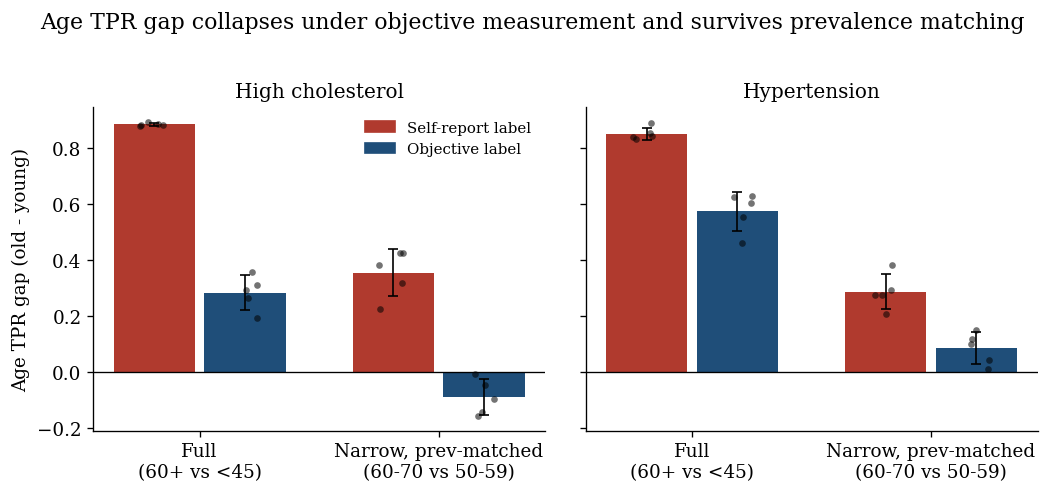

saved fig2_injection_sufficiency


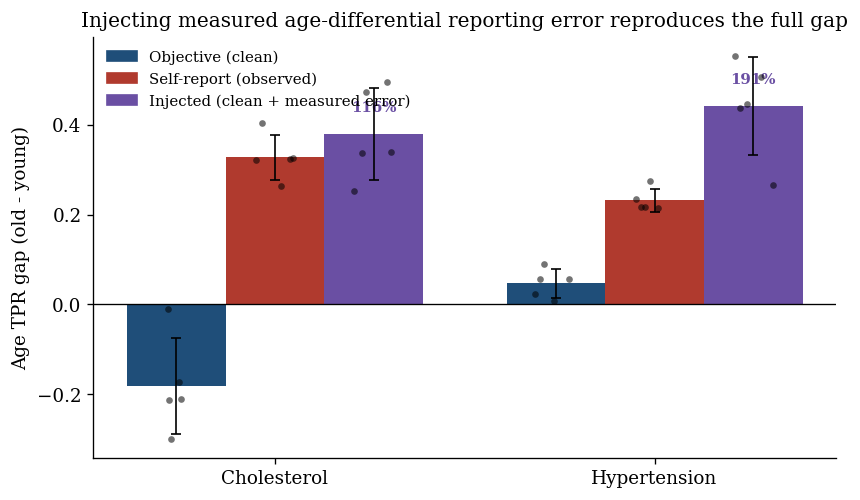

saved fig3_two_mode_contrast


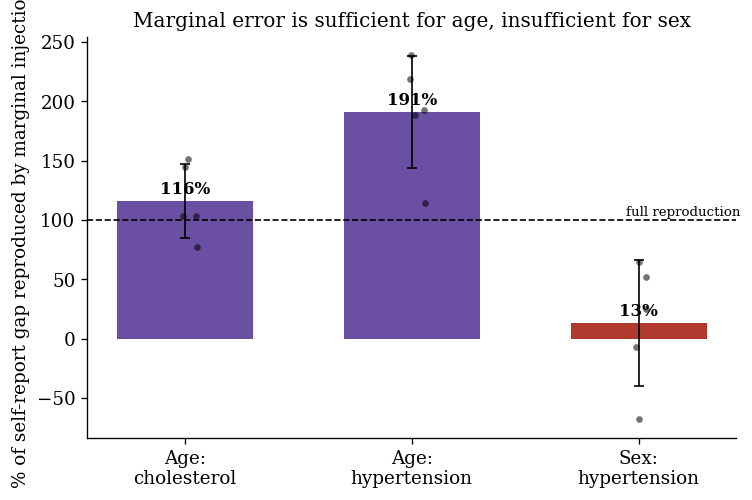

/content/drive/MyDrive/EXHEART_Research/exheart-research
[main 18fd457] Figures 1-3 with per-seed replicate dots and SD error bars
 9 files changed, 53 insertions(+), 1 deletion(-)
 create mode 100644 results/nhanes_instrument_probe/figures/fig1_instrument_portability.pdf
 create mode 100644 results/nhanes_instrument_probe/figures/fig1_instrument_portability.png
 create mode 100644 results/nhanes_instrument_probe/figures/fig2_injection_sufficiency.pdf
 create mode 100644 results/nhanes_instrument_probe/figures/fig2_injection_sufficiency.png
 create mode 100644 results/nhanes_instrument_probe/figures/fig3_two_mode_contrast.pdf
 create mode 100644 results/nhanes_instrument_probe/figures/fig3_two_mode_contrast.png
 create mode 100644 results/nhanes_instrument_probe/tables/age_gate_perseed.csv
 create mode 100644 results/nhanes_instrument_probe/tables/age_injection_perseed.csv
Enumerating objects: 23, done.
Counting objects: 100% (23/23), done.
Delta compression using up to 2 threads
Compr

In [27]:
# === Figures 1-3 with per-seed replicate dots + SD bars (patched sex-file reader), then commit ===
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, os, matplotlib.pyplot as plt
from matplotlib.patches import Patch
plt.rcParams.update({'font.family':'serif','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'axes.titlesize':12})
SR,OBJ,INJ='#B03A2E','#1F4E79','#6A4FA3'; T=TAB_DIR; FIG=FIG_DIR; rng=np.random.default_rng(0)

def save(fig,n):
    fig.savefig(os.path.join(FIG,n+'.png'),dpi=300,bbox_inches='tight')
    fig.savefig(os.path.join(FIG,n+'.pdf'),bbox_inches='tight'); print('saved',n)
def dots(ax,x,vals):
    v=np.array([q for q in vals if np.isfinite(q)])
    ax.scatter(x+(rng.random(len(v))-0.5)*0.12,v,s=16,color='k',alpha=0.55,zorder=5,linewidths=0)
    if len(v)>1: ax.errorbar(x,v.mean(),yerr=v.std(ddof=1),fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=4)

# ---- Figure 1: instrument portability + confound gate ----
gp=pd.read_csv(os.path.join(T,'age_gate_perseed.csv')); cons=['cholesterol','hypertension']; tt=['High cholesterol','Hypertension']
fig,axes=plt.subplots(1,2,figsize=(9,4),sharey=True)
for ax,c,t in zip(axes,cons,tt):
    for (bnd,lk),x,col in zip([('full','sr'),('full','obj'),('narrow','sr'),('narrow','obj')],[-0.19,0.19,0.81,1.19],[SR,OBJ,SR,OBJ]):
        v=gp[(gp.construct==c)&(gp.band==bnd)&(gp.label==lk)].gap.values
        ax.bar(x,np.nanmean(v),0.34,color=col); dots(ax,x,v)
    ax.axhline(0,color='k',lw=0.8); ax.set_xticks([0,1])
    ax.set_xticklabels(['Full\n(60+ vs <45)','Narrow, prev-matched\n(60-70 vs 50-59)']); ax.set_title(t)
    ax.set_ylabel('Age TPR gap (old - young)' if c==cons[0] else '')
axes[0].legend(handles=[Patch(color=SR,label='Self-report label'),Patch(color=OBJ,label='Objective label')],frameon=False,fontsize=9)
fig.suptitle('Age TPR gap collapses under objective measurement and survives prevalence matching',y=1.02)
fig.tight_layout(); save(fig,'fig1_instrument_portability'); plt.show()

# ---- Figure 2: injection sufficiency + sign flip ----
ip=pd.read_csv(os.path.join(T,'age_injection_perseed.csv')); fig,ax=plt.subplots(figsize=(7.2,4.3))
cons2=list(ip.construct.unique()); X=np.arange(len(cons2)); w=0.26
for xi,c in zip(X,cons2):
    for dx,key,col in [(-w,'gap_objective',OBJ),(0,'gap_self_report',SR),(w,'gap_injected',INJ)]:
        v=ip[ip.construct==c][key].values; ax.bar(xi+dx,np.nanmean(v),w,color=col); dots(ax,xi+dx,v)
    frac=ip[ip.construct==c].gap_injected.mean()/ip[ip.construct==c].gap_self_report.mean()*100
    ax.text(xi+w,ip[ip.construct==c].gap_injected.mean()+0.05,f'{frac:.0f}%',ha='center',color=INJ,fontweight='bold',fontsize=9)
ax.axhline(0,color='k',lw=0.8); ax.set_xticks(X); ax.set_xticklabels([c.capitalize() for c in cons2]); ax.set_ylabel('Age TPR gap (old - young)')
ax.legend(handles=[Patch(color=OBJ,label='Objective (clean)'),Patch(color=SR,label='Self-report (observed)'),Patch(color=INJ,label='Injected (clean + measured error)')],frameon=False,fontsize=9,loc='upper left')
ax.set_title('Injecting measured age-differential reporting error reproduces the full gap'); fig.tight_layout(); save(fig,'fig2_injection_sufficiency'); plt.show()

# ---- Figure 3: marginal-injection recovery, age vs sex (PATCHED sex reader) ----
sx=pd.read_csv(os.path.join(T,'step3_label_injection.csv'),on_bad_lines='skip',engine='python')
sx=sx[pd.to_numeric(sx['seed'],errors='coerce').notna()].copy()
for cc in ['gap_injected','gap_self_report']: sx[cc]=sx[cc].astype(float)
groups=[('Age:\ncholesterol',ip[ip.construct=='cholesterol']),('Age:\nhypertension',ip[ip.construct=='hypertension']),('Sex:\nhypertension',sx)]
fig,ax=plt.subplots(figsize=(6.4,4.3))
for i,(lab,d) in enumerate(groups):
    srm=d.gap_self_report.mean(); barval=d.gap_injected.mean()/srm*100; col=INJ if lab.startswith('Age') else SR
    ax.bar(i,barval,0.6,color=col); dots(ax,i,[v/srm*100 for v in d.gap_injected.values])
    ax.text(i,barval+6,f'{barval:.0f}%',ha='center',fontsize=10,fontweight='bold')
ax.axhline(100,color='k',ls='--',lw=1); ax.text(2.45,104,'full reproduction',ha='right',fontsize=8)
ax.set_xticks(range(3)); ax.set_xticklabels([g[0] for g in groups]); ax.set_ylabel('% of self-report gap reproduced by marginal injection')
ax.set_title('Marginal error is sufficient for age, insufficient for sex'); fig.tight_layout(); save(fig,'fig3_two_mode_contrast'); plt.show()

# ---- commit ----
%cd {REPO_DIR}
!git add -A
!git -c user.name="Md Anas Biswas" -c user.email="anasbiswas@gmail.com" commit -m "Figures 1-3 with per-seed replicate dots and SD error bars"
!git push origin main
print('committed. Upload the three PNGs here.')